importation

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import os

Matplotlib is building the font cache; this may take a moment.


Chargement et noms de colonnes

In [2]:
df = pd.read_csv('wdbc.data', header=None)
col_names = ['id', 'diagnosis',
             'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
             'smoothness_mean', 'compactness_mean', 'concavity_mean',
             'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
             'radius_se', 'texture_se', 'perimeter_se', 'area_se',
             'smoothness_se', 'compactness_se', 'concavity_se',
             'concave points_se', 'symmetry_se', 'fractal_dimension_se',
             'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
             'smoothness_worst', 'compactness_worst', 'concavity_worst',
             'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
df.columns = col_names
df.drop('id', axis=1, inplace=True)
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


Exploration initiale

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['diagnosis'].value_counts(normalize=True) * 100)

(569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  56

Statistiques et skewness

In [4]:
print(df.describe())
num_cols = df.select_dtypes(include=['float64']).columns
for col in list(num_cols)[:5]:
    print(f"{col}: skew={skew(df[col]):.3f}, kurtosis={kurtosis(df[col]):.3f}")

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

Comparaison par classe

In [5]:
grouped = df.groupby('diagnosis').mean()
diff = abs(grouped.loc['M'] - grouped.loc['B']).sort_values(ascending=False)
print(diff.head(5))

area_worst         863.386881
area_mean          515.586219
perimeter_worst     54.364392
area_se             51.537257
perimeter_mean      37.289971
dtype: float64


Détection outliers et boxplots

radius_mean: 14 outliers (2.46%)


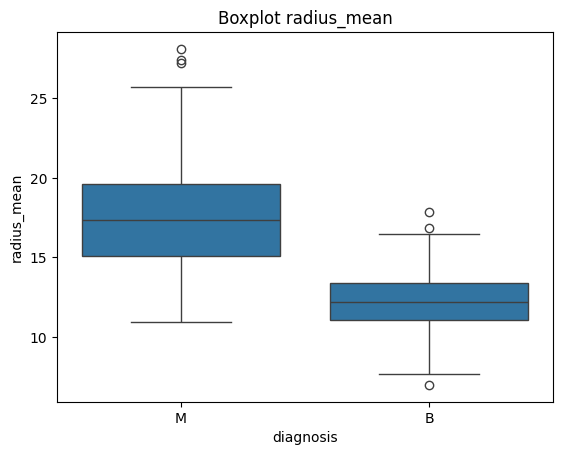

area_mean: 25 outliers (4.39%)


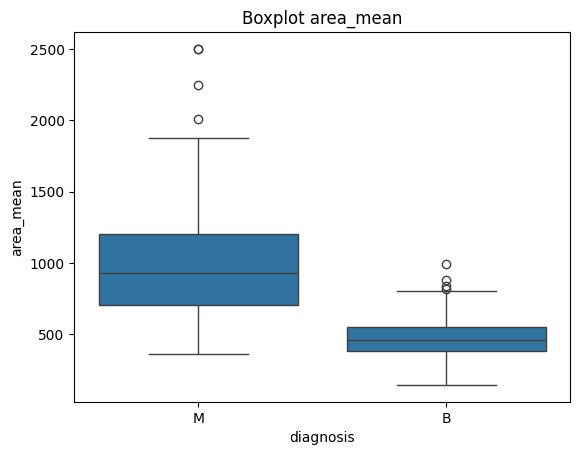

smoothness_mean: 6 outliers (1.05%)


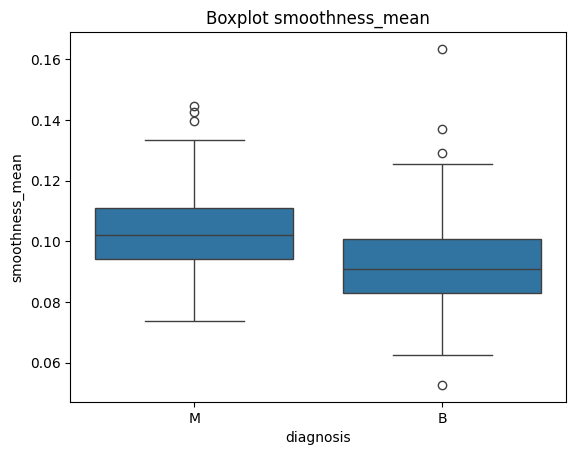

In [6]:
def iqr_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5*IQR
    high = Q3 + 1.5*IQR
    out = data[(data[col] < low) | (data[col] > high)]
    return len(out), len(out)/len(data)*100

os.makedirs('graphs', exist_ok=True)
for col in ['radius_mean', 'area_mean', 'smoothness_mean']:
    n, p = iqr_outliers(df, col)
    print(f"{col}: {n} outliers ({p:.2f}%)")
    plt.figure()
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'Boxplot {col}')
    plt.savefig(f'graphs/boxplot_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

Transformation log

radius_se: skew avant 3.080 → après 1.709


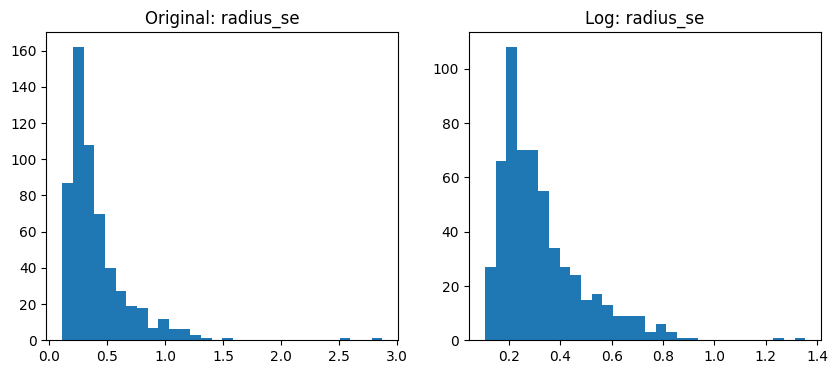

perimeter_se: skew avant 3.435 → après 1.023


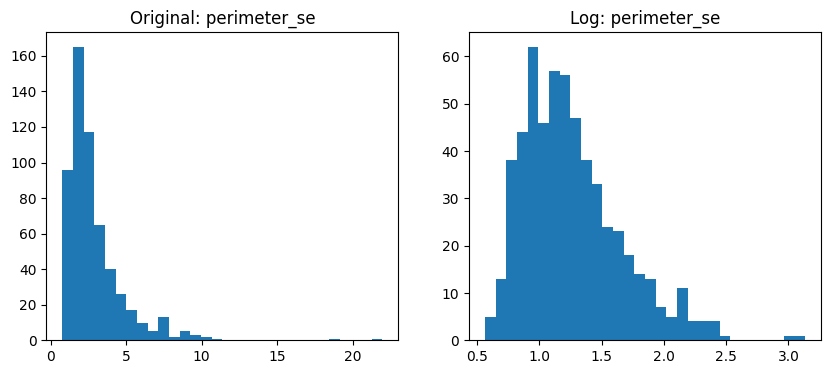

area_se: skew avant 5.433 → après 0.845


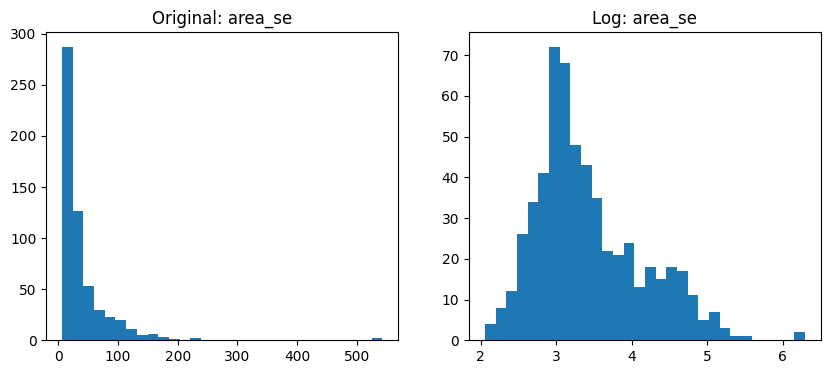

smoothness_se: skew avant 2.308 → après 2.277


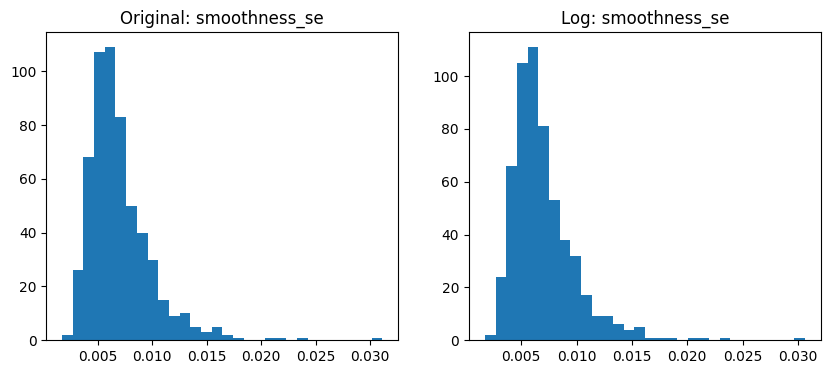

concavity_se: skew avant 5.097 → après 4.221


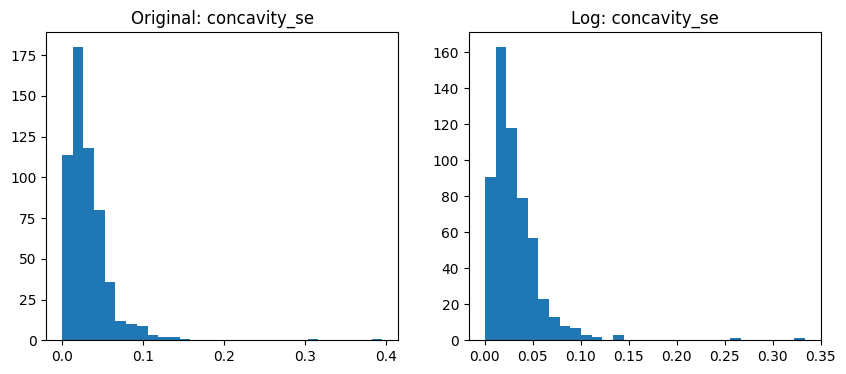

symmetry_se: skew avant 2.189 → après 2.130


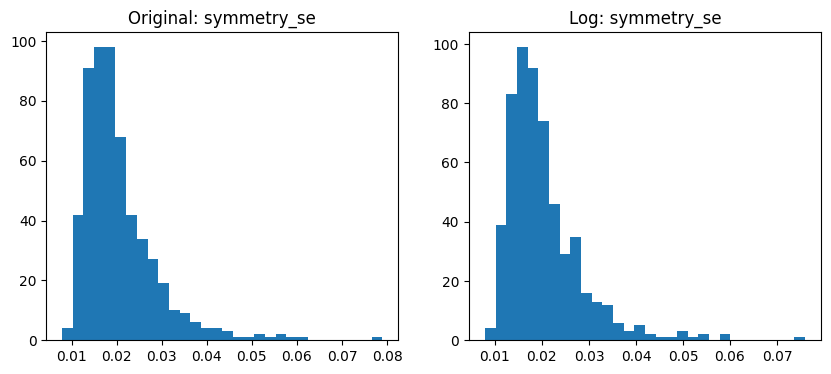

fractal_dimension_se: skew avant 3.914 → après 3.864


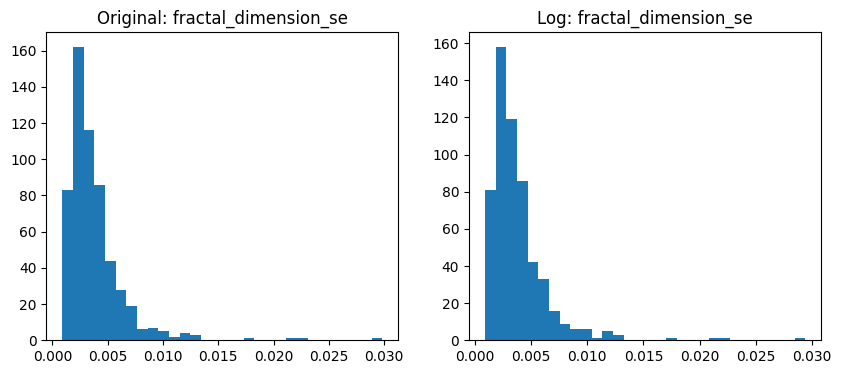

In [7]:
skew_vals = df[num_cols].apply(lambda x: skew(x.dropna()))
high_skew = skew_vals[abs(skew_vals) > 2].index.tolist()
for var in high_skew:
    df[f'{var}_log'] = np.log1p(df[var])
    print(f"{var}: skew avant {skew(df[var]):.3f} → après {skew(df[f'{var}_log']):.3f}")
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.hist(df[var], bins=30)
    ax1.set_title(f'Original: {var}')
    ax2.hist(df[f'{var}_log'], bins=30)
    ax2.set_title(f'Log: {var}')
    plt.savefig(f'graphs/log_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()

sauvegarde finale 

In [8]:
df.to_csv('breast_cancer_cleaned.csv', index=False)
print("Fichier sauvegardé : breast_cancer_cleaned.csv")

Fichier sauvegardé : breast_cancer_cleaned.csv
